In [11]:
print("Hello! Alfido Tech AI Project Started 🚀")

Hello! Alfido Tech AI Project Started 🚀


In [12]:
# Import required libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)

import warnings
warnings.filterwarnings("ignore")

# Reproducibility
RANDOM_STATE = 42

print("Libraries imported successfully! ✅")

Libraries imported successfully! ✅


In [13]:
# Download the SMS Spam Collection dataset

!wget -q https://archive.ics.uci.edu/static/public/228/sms+spam+collection.zip

# Extract the dataset
!unzip -o -q "sms+spam+collection.zip"

print("Dataset downloaded successfully! ✅")

Dataset downloaded successfully! ✅


In [14]:
# Load the SMS Spam Collection dataset

df = pd.read_csv(
    "SMSSpamCollection",
    sep="\t",
    header=None,
    names=["label", "message"]
)

print("Dataset loaded successfully! ✅")
print("Dataset shape:", df.shape)

df.head()

Dataset loaded successfully! ✅
Dataset shape: (5572, 2)


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [15]:
# Basic information about the dataset

print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nColumn names:")
print(df.columns.tolist())

print("\nDataset information:")
df.info()

Number of rows: 5572
Number of columns: 2

Column names:
['label', 'message']

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5572 non-null   object
 1   message  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [16]:
# Count the number of spam and ham messages

print("Message counts:")
print(df["label"].value_counts())

Message counts:
label
ham     4825
spam     747
Name: count, dtype: int64


In [17]:
# Check for missing values

print("Missing values:")
print(df.isnull().sum())

Missing values:
label      0
message    0
dtype: int64


In [18]:
# Check duplicate rows

print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 403


In [19]:
# Remove duplicate messages

print("Rows before removing duplicates:", len(df))

df = df.drop_duplicates().reset_index(drop=True)

print("Rows after removing duplicates:", len(df))
print("Duplicates removed:", df.duplicated().sum())

Rows before removing duplicates: 5572
Rows after removing duplicates: 5169
Duplicates removed: 0


In [20]:
# Check missing values after cleaning

print("Missing values after cleaning:")
print(df.isnull().sum())

Missing values after cleaning:
label      0
message    0
dtype: int64


In [21]:
# Convert labels into numerical values

df["label_encoded"] = df["label"].map({
    "ham": 0,
    "spam": 1
})

print(df.head())

  label                                            message  label_encoded
0   ham  Go until jurong point, crazy.. Available only ...              0
1   ham                      Ok lar... Joking wif u oni...              0
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...              1
3   ham  U dun say so early hor... U c already then say...              0
4   ham  Nah I don't think he goes to usf, he lives aro...              0


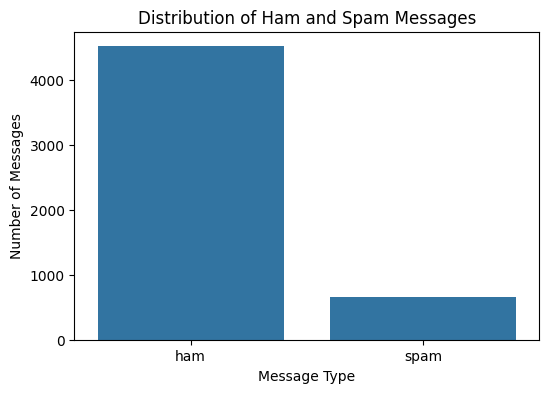

In [22]:
# Visualize the distribution of Ham and Spam messages

plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="label")

plt.title("Distribution of Ham and Spam Messages")
plt.xlabel("Message Type")
plt.ylabel("Number of Messages")

plt.show()

In [23]:
# Calculate the percentage of each message type

label_counts = df["label"].value_counts()
label_percentages = df["label"].value_counts(normalize=True) * 100

print("Message Counts:")
print(label_counts)

print("\nMessage Percentages:")
print(label_percentages.round(2))

Message Counts:
label
ham     4516
spam     653
Name: count, dtype: int64

Message Percentages:
label
ham     87.37
spam    12.63
Name: proportion, dtype: float64


In [24]:
# Calculate the length of each SMS

df["message_length"] = df["message"].str.len()

print("Message length statistics:")
print(df["message_length"].describe())


Message length statistics:
count    5169.000000
mean       79.344554
std        58.437457
min         2.000000
25%        36.000000
50%        61.000000
75%       119.000000
max       910.000000
Name: message_length, dtype: float64


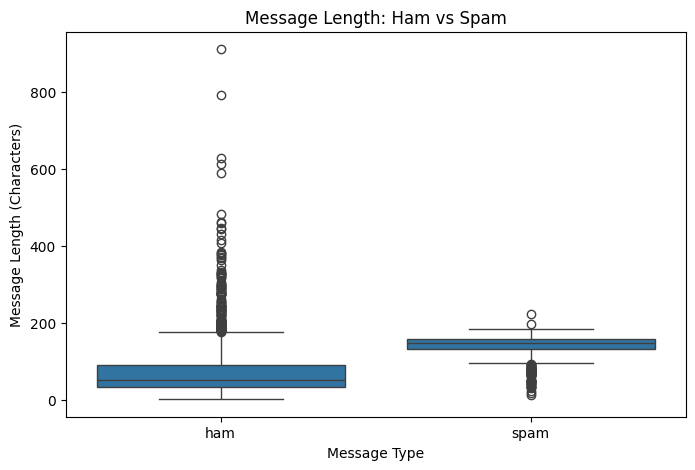

In [25]:
# Compare message length between Ham and Spam

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="label",
    y="message_length"
)

plt.title("Message Length: Ham vs Spam")
plt.xlabel("Message Type")
plt.ylabel("Message Length (Characters)")

plt.show()

In [26]:
# Separate features and target

X = df["message"]
y = df["label_encoded"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (5169,)
Target shape: (5169,)


In [27]:
# Split the dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print("\nTraining class distribution:")
print(y_train.value_counts())

print("\nTesting class distribution:")
print(y_test.value_counts())

Training samples: 4135
Testing samples: 1034

Training class distribution:
label_encoded
0    3613
1     522
Name: count, dtype: int64

Testing class distribution:
label_encoded
0    903
1    131
Name: count, dtype: int64


In [28]:
# Create TF-IDF vectorizer

tfidf = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    ngram_range=(1, 2),
    max_features=5000
)

# Learn vocabulary only from training data
X_train_tfidf = tfidf.fit_transform(X_train)

# Transform test data using the same vocabulary
X_test_tfidf = tfidf.transform(X_test)

print("TF-IDF vectorization completed! ✅")
print("Training matrix shape:", X_train_tfidf.shape)
print("Testing matrix shape:", X_test_tfidf.shape)

TF-IDF vectorization completed! ✅
Training matrix shape: (4135, 5000)
Testing matrix shape: (1034, 5000)


In [31]:
# Train Logistic Regression model

logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=RANDOM_STATE
)

logistic_model.fit(X_train_tfidf, y_train)

print("Logistic Regression model trained successfully! ✅")

Logistic Regression model trained successfully! ✅


In [32]:
# Make predictions using Logistic Regression

y_pred_lr = logistic_model.predict(X_test_tfidf)
y_prob_lr = logistic_model.predict_proba(X_test_tfidf)[:, 1]

print("Predictions generated successfully! ✅")
print("First 10 predictions:", y_pred_lr[:10])


Predictions generated successfully! ✅
First 10 predictions: [0 0 0 0 0 0 0 0 0 0]


In [33]:
# Evaluate Logistic Regression

lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_precision = precision_score(y_test, y_pred_lr)
lr_recall = recall_score(y_test, y_pred_lr)
lr_f1 = f1_score(y_test, y_pred_lr)
lr_roc_auc = roc_auc_score(y_test, y_prob_lr)

print("Logistic Regression Results")
print("-" * 35)
print(f"Accuracy : {lr_accuracy:.4f}")
print(f"Precision: {lr_precision:.4f}")
print(f"Recall   : {lr_recall:.4f}")
print(f"F1-Score : {lr_f1:.4f}")
print(f"ROC-AUC  : {lr_roc_auc:.4f}")

Logistic Regression Results
-----------------------------------
Accuracy : 0.9565
Precision: 0.9778
Recall   : 0.6718
F1-Score : 0.7964
ROC-AUC  : 0.9920


In [34]:
# Train Random Forest model

random_forest_model = RandomForestClassifier(
    n_estimators=300,
    random_state=RANDOM_STATE,
    class_weight="balanced"
)

random_forest_model.fit(X_train_tfidf, y_train)

print("Random Forest model trained successfully! ✅")

Random Forest model trained successfully! ✅


In [35]:
# Make predictions using Random Forest

y_pred_rf = random_forest_model.predict(X_test_tfidf)
y_prob_rf = random_forest_model.predict_proba(X_test_tfidf)[:, 1]

print("Random Forest predictions generated successfully! ✅")
print("First 10 predictions:", y_pred_rf[:10])

Random Forest predictions generated successfully! ✅
First 10 predictions: [0 0 0 0 0 0 0 0 0 0]


In [36]:
# Evaluate Random Forest

rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)
rf_roc_auc = roc_auc_score(y_test, y_prob_rf)

print("Random Forest Results")
print("-" * 35)
print(f"Accuracy : {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall   : {rf_recall:.4f}")
print(f"F1-Score : {rf_f1:.4f}")
print(f"ROC-AUC  : {rf_roc_auc:.4f}")

Random Forest Results
-----------------------------------
Accuracy : 0.9797
Precision: 1.0000
Recall   : 0.8397
F1-Score : 0.9129
ROC-AUC  : 0.9936


In [37]:
# Set up Stratified 5-Fold Cross-Validation

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

print("5-Fold Stratified Cross-Validation is ready! ✅")

5-Fold Stratified Cross-Validation is ready! ✅


In [38]:
# Create pipelines for Cross-Validation
# TF-IDF is fitted separately inside each fold to prevent data leakage.

lr_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        lowercase=True,
        stop_words="english",
        ngram_range=(1, 2),
        max_features=5000
    )),
    ("classifier", LogisticRegression(
        max_iter=1000,
        random_state=RANDOM_STATE
    ))
])

rf_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        lowercase=True,
        stop_words="english",
        ngram_range=(1, 2),
        max_features=5000
    )),
    ("classifier", RandomForestClassifier(
        n_estimators=300,
        random_state=RANDOM_STATE,
        class_weight="balanced"
    ))
])

print("Both ML pipelines created successfully! ✅")

Both ML pipelines created successfully! ✅


In [39]:
# Define the evaluation metrics

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

print("Evaluation metrics defined! ✅")

Evaluation metrics defined! ✅


In [40]:
# Perform 5-Fold Cross-Validation

lr_cv_results = cross_validate(
    lr_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

rf_cv_results = cross_validate(
    rf_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

print("Cross-validation completed successfully! ✅")

Cross-validation completed successfully! ✅


In [41]:
# Complete 5-Fold Cross-Validation + Results

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

lr_cv_results = cross_validate(
    lr_pipeline, X_train, y_train,
    cv=cv, scoring=scoring, n_jobs=-1
)

rf_cv_results = cross_validate(
    rf_pipeline, X_train, y_train,
    cv=cv, scoring=scoring, n_jobs=-1
)

# Create comparison table
cv_summary = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"],
    "Logistic Regression": [
        lr_cv_results["test_accuracy"].mean(),
        lr_cv_results["test_precision"].mean(),
        lr_cv_results["test_recall"].mean(),
        lr_cv_results["test_f1"].mean(),
        lr_cv_results["test_roc_auc"].mean()
    ],
    "Random Forest": [
        rf_cv_results["test_accuracy"].mean(),
        rf_cv_results["test_precision"].mean(),
        rf_cv_results["test_recall"].mean(),
        rf_cv_results["test_f1"].mean(),
        rf_cv_results["test_roc_auc"].mean()
    ]
})

print("5-Fold Cross-Validation completed! ✅")
display(cv_summary.round(4))

5-Fold Cross-Validation completed! ✅


,Metric,Logistic Regression,Random Forest
0,Accuracy,0.9543,0.9717
1,Precision,0.9850,0.9926
2,Recall,0.6476,0.7816
3,F1-Score,0.7806,0.8741
4,ROC-AUC,0.9875,0.9867


,Metric,Logistic Regression,Random Forest
0,Accuracy,0.9565,0.9797
1,Precision,0.9778,1.0000
2,Recall,0.6718,0.8397
3,F1-Score,0.7964,0.9129
4,ROC-AUC,0.9920,0.9936


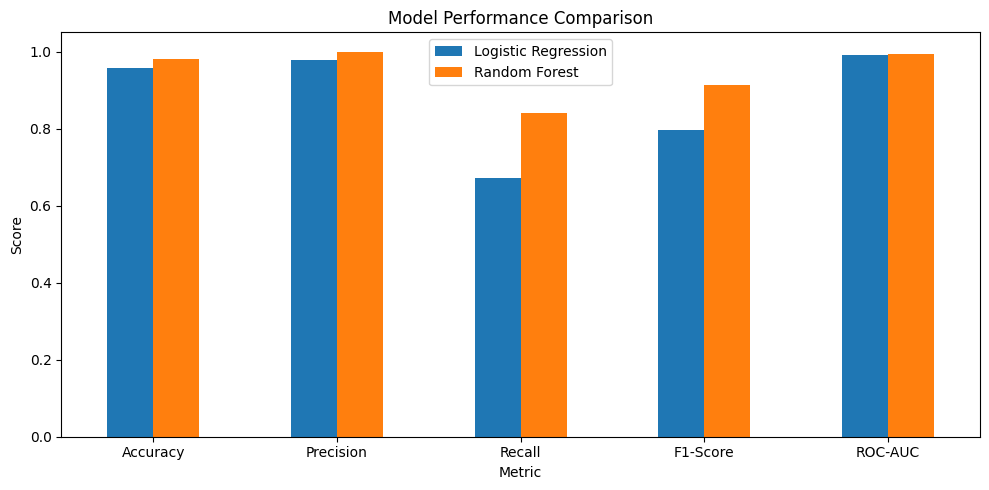

In [42]:
# Final comparison of both models

results = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"],
    "Logistic Regression": [
        lr_accuracy, lr_precision, lr_recall, lr_f1, lr_roc_auc
    ],
    "Random Forest": [
        rf_accuracy, rf_precision, rf_recall, rf_f1, rf_roc_auc
    ]
})

display(results.round(4))

# Plot comparison
results_plot = results.set_index("Metric")

results_plot.plot(kind="bar", figsize=(10, 5))
plt.ylim(0, 1.05)
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.legend()
plt.tight_layout()
plt.show()

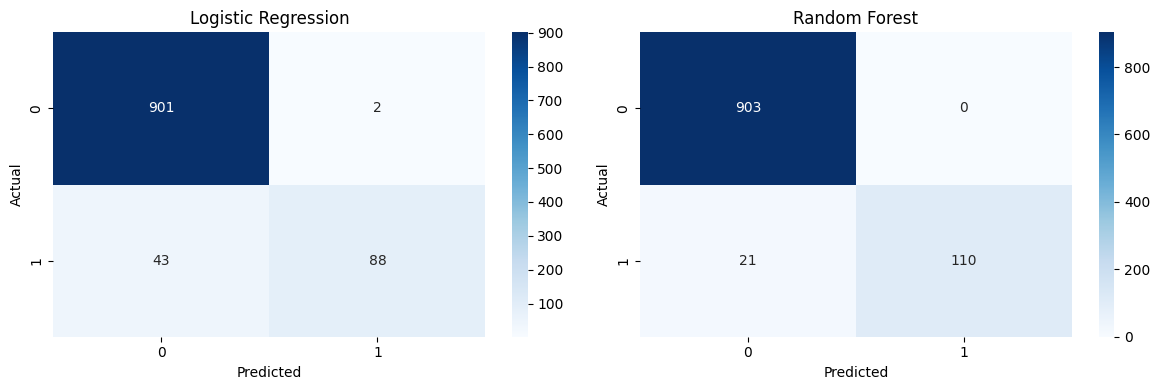

<Figure size 800x600 with 0 Axes>

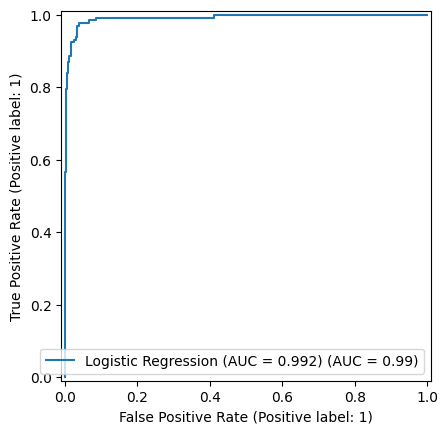

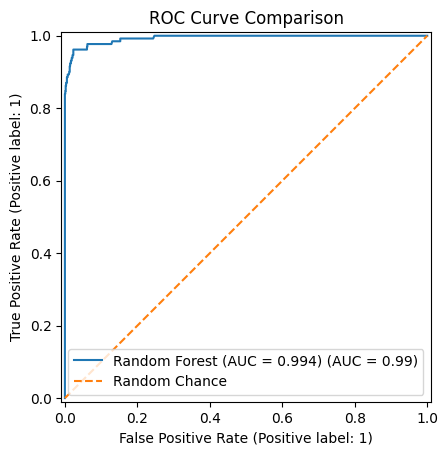

In [43]:
# Confusion Matrices

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

cm_lr = confusion_matrix(y_test, y_pred_lr)
cm_rf = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm_lr, annot=True, fmt="d", cmap="Blues", ax=axes[0])
axes[0].set_title("Logistic Regression")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Blues", ax=axes[1])
axes[1].set_title("Random Forest")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()


# ROC Curves

plt.figure(figsize=(8, 6))

RocCurveDisplay.from_predictions(
    y_test, y_prob_lr,
    name=f"Logistic Regression (AUC = {lr_roc_auc:.3f})"
)

RocCurveDisplay.from_predictions(
    y_test, y_prob_rf,
    name=f"Random Forest (AUC = {rf_roc_auc:.3f})"
)

plt.plot([0, 1], [0, 1], "--", label="Random Chance")

plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

In [44]:
import joblib

# Save the trained Random Forest model
joblib.dump(random_forest_model, "spam_random_forest_model.pkl")

# Save the TF-IDF vectorizer
joblib.dump(tfidf, "tfidf_vectorizer.pkl")

print("Random Forest model saved! ✅")
print("TF-IDF vectorizer saved! ✅")

Random Forest model saved! ✅
TF-IDF vectorizer saved! ✅


In [45]:
# Test the spam detection model with custom messages

test_messages = [
    "Congratulations! You have won a free prize. Click now to claim.",
    "Hey, are we meeting tomorrow at 5 pm?"
]

test_vectors = tfidf.transform(test_messages)
predictions = random_forest_model.predict(test_vectors)
probabilities = random_forest_model.predict_proba(test_vectors)[:, 1]

for message, prediction, probability in zip(
    test_messages, predictions, probabilities
):
    result = "SPAM 🚨" if prediction == 1 else "HAM ✅"

    print("Message:", message)
    print("Prediction:", result)
    print(f"Spam Probability: {probability:.2%}")
    print("-" * 60)

Message: Congratulations! You have won a free prize. Click now to claim.
Prediction: SPAM 🚨
Spam Probability: 71.67%
------------------------------------------------------------
Message: Hey, are we meeting tomorrow at 5 pm?
Prediction: HAM ✅
Spam Probability: 0.33%
------------------------------------------------------------


## Conclusion

This project developed an SMS spam detection system using Natural Language Processing and supervised machine learning.

The SMS Spam Collection dataset was cleaned and explored before being divided into training and testing sets using an 80:20 stratified split. TF-IDF vectorization was used to convert text messages into numerical features.

Two classification algorithms were compared:

1. Logistic Regression
2. Random Forest Classifier

Both models were evaluated using stratified 5-fold cross-validation and the required metrics: Accuracy, Precision, Recall, F1-Score, and ROC-AUC.

Based on the test-set results, Random Forest achieved better overall performance than Logistic Regression:

- Accuracy: 97.97%
- Precision: 100.00%
- Recall: 83.97%
- F1-Score: 91.29%
- ROC-AUC: 99.36%

Therefore, Random Forest was selected as the final model.

The trained Random Forest model and TF-IDF vectorizer were saved as reusable files. Custom SMS testing also demonstrated that the model can distinguish between likely spam and legitimate messages.

Overall, this project demonstrates a complete machine-learning workflow from data preprocessing and NLP feature extraction to model training, cross-validation, evaluation, comparison, and prediction.

In [46]:
# Final Model Evaluation Summary

final_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC"
    ],
    "Logistic Regression": [
        lr_accuracy,
        lr_precision,
        lr_recall,
        lr_f1,
        lr_roc_auc
    ],
    "Random Forest": [
        rf_accuracy,
        rf_precision,
        rf_recall,
        rf_f1,
        rf_roc_auc
    ]
})

print("FINAL MODEL COMPARISON")
print("=" * 50)

display(final_results.round(4))

FINAL MODEL COMPARISON


,Metric,Logistic Regression,Random Forest
0,Accuracy,0.9565,0.9797
1,Precision,0.9778,1.0000
2,Recall,0.6718,0.8397
3,F1-Score,0.7964,0.9129
4,ROC-AUC,0.9920,0.9936


In [47]:
# Cross-Validation Summary

cv_summary = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"],
    "Logistic Regression Mean": [
        lr_cv_results["test_accuracy"].mean(),
        lr_cv_results["test_precision"].mean(),
        lr_cv_results["test_recall"].mean(),
        lr_cv_results["test_f1"].mean(),
        lr_cv_results["test_roc_auc"].mean()
    ],
    "Logistic Regression Std": [
        lr_cv_results["test_accuracy"].std(),
        lr_cv_results["test_precision"].std(),
        lr_cv_results["test_recall"].std(),
        lr_cv_results["test_f1"].std(),
        lr_cv_results["test_roc_auc"].std()
    ],
    "Random Forest Mean": [
        rf_cv_results["test_accuracy"].mean(),
        rf_cv_results["test_precision"].mean(),
        rf_cv_results["test_recall"].mean(),
        rf_cv_results["test_f1"].mean(),
        rf_cv_results["test_roc_auc"].mean()
    ],
    "Random Forest Std": [
        rf_cv_results["test_accuracy"].std(),
        rf_cv_results["test_precision"].std(),
        rf_cv_results["test_recall"].std(),
        rf_cv_results["test_f1"].std(),
        rf_cv_results["test_roc_auc"].std()
    ]
})

display(cv_summary.round(4))

,Metric,Logistic Regression Mean,Logistic Regression Std,Random Forest Mean,Random Forest Std
0,Accuracy,0.9543,0.0069,0.9717,0.0057
1,Precision,0.9850,0.0093,0.9926,0.0100
2,Recall,0.6476,0.0496,0.7816,0.0411
3,F1-Score,0.7806,0.0375,0.8741,0.0274
4,ROC-AUC,0.9875,0.0030,0.9867,0.0038


In [48]:
import sys
import numpy
import pandas
import sklearn
import matplotlib
import seaborn
import joblib

print("Python:", sys.version)
print("NumPy:", numpy.__version__)
print("Pandas:", pandas.__version__)
print("Scikit-learn:", sklearn.__version__)
print("Matplotlib:", matplotlib.__version__)
print("Seaborn:", seaborn.__version__)
print("Joblib:", joblib.__version__)

Python: 3.13.15 (main, Aug  6 2026, 11:06:23) [GCC 11.4.0]
NumPy: 2.1.3
Pandas: 2.2.3
Scikit-learn: 1.6.1
Matplotlib: 3.10.0
Seaborn: 0.13.2
Joblib: 1.5.3
